# LOAD LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math
import json
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import shap
from diive.core.io.files import save_parquet, load_parquet
from datetime import datetime

# CONFIGURATION

In [2]:
START_DATE, END_DATE = '2023-11-08', '2025-06-05'
TARGET_FLUX = 'NEE'
N_FOLDS = 10
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
CROSSVAL_SPLIT = 'time_blocks_eliza' # options: 'shuffle' or 'kfold' or 'custom_time_blocks' or 'time_blocks_eliza'
PARCEL_CERTAIN = False
LOG_TRANSFORM = False
ADD_ID = True
UNDERSAMPLE = False
ADD_TRT = False # Set to False because we don't have enough nighttime data from parcel A so we assume no difference between parcels during nighttime

# LOAD DATA

In [3]:
data_main = fluxes = load_parquet(filepath=r"81.1.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()
maindf = data_main.copy()

# Add an id column to account for the proximity of values as the timestamp is continuous without gaps
if ADD_ID:
    data_main['id'] = range(0, len(data_main))
    print("\nAdded 'id' variable --> indexing number starting from zero")
else:
    print('\nNot using index variable')

data_main

Loaded .parquet file 81.1.1_GapFillingDataset.parquet (0.637 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 

Added 'id' variable --> indexing number starting from zero


,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,parcel,parcel_certainty,trt,SW_IN_POT,prec,ta,ppfd,sw_in,rh,...,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,LAI,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,-0.111997,-3.231648,NaN,NaN,-3.231648,B,certain,1.0,0.0,0.0,5.333333,0.0,0.0,79.833333,...,-0.193433,-0.188894,0.055964,-1.641550,-0.086146,0.576043,0.0,0.0,2.185170,0.986663,29.0,22.0,0.300700,5.004348,0
2023-11-08 00:45:00,NaN,0.100302,NaN,NaN,0.100302,NaN,B,certain,1.0,0.0,0.0,5.966667,0.0,0.0,77.500000,...,-0.051464,0.009568,0.016644,-2.340741,0.001028,0.291943,0.0,0.0,2.179702,0.983564,29.0,22.0,0.300704,5.004376,1
2023-11-08 01:15:00,NaN,0.239428,NaN,NaN,0.239428,NaN,B,certain,1.0,0.0,0.0,5.833333,0.0,0.0,77.366667,...,-0.146880,0.084459,0.138010,-0.829823,0.242660,0.618842,0.0,0.0,2.174248,0.980476,29.0,22.0,0.300709,5.004405,2
2023-11-08 01:45:00,NaN,-0.184917,6.746138,NaN,NaN,NaN,B,certain,1.0,0.0,0.0,5.866667,0.0,0.0,77.100000,...,-0.234554,-0.023746,0.307449,-0.724752,0.260016,0.686303,0.0,0.0,2.168807,0.977400,29.0,22.0,0.300714,5.004433,3
2023-11-08 02:15:00,NaN,0.358358,3.168362,NaN,0.358358,3.168362,B,certain,1.0,0.0,0.0,5.766667,0.0,0.0,77.166667,...,-0.187335,-0.028905,0.178615,-0.724348,0.032634,0.695635,0.0,0.0,2.163380,0.974334,29.0,22.0,0.300718,5.004462,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,0.0,15.833333,0.0,0.0,84.166667,...,-1.379082,-1.916712,-1.061214,-4.208609,-5.629534,-3.817729,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27643
2025-06-05 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,0.0,15.733333,0.0,0.0,83.833333,...,-1.091476,-1.879544,-0.962736,-4.909742,-6.854152,-4.700644,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27644
2025-06-05 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,0.0,16.200000,0.0,0.0,78.066667,...,-1.190896,-1.739450,-0.961502,-4.913663,-6.580284,-4.667567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27645


# CLEAN DATA

In [4]:
TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_QCF0'
print(f'The target variable is {TARGET}')

mean_nan_size = (
    data_main[TARGET]
    .isna()
    .ne(data_main[TARGET].isna().shift())
    .cumsum()
    .where(data_main[TARGET].isna())
    .dropna()
    .value_counts()
    .mean()
)
print("\nMean size of consecutive NaNs in the target variable:", mean_nan_size)

# Remove NAs of the target
data = data_main[data_main[TARGET].notna()].copy()

# Keep only data where we are sure about parcel attribution
if PARCEL_CERTAIN:
    data = data[data['parcel_certainty'] == 'certain'].copy()
    print('\nKeeping only data when we are highly confident on the parcel attribution')
else:
    print('\nKeeping also data from mixed parcel contribution')

The target variable is NEE_L3.3_CUT_50_QCF0

Mean size of consecutive NaNs in the target variable: 5.8394768133174795

Keeping also data from mixed parcel contribution


# SELECT FEATURES

In [5]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

# selected_features = [
#     'SW_IN_POT',
#     'ppfd',
#     'timesince_soil_preparation',
#     'timesince_sowing',
#     'n_decay_timed',
#     'ts_0.3_gfXG_roll3hmean'
# ]

# If ADD_TRT is True we add the trt variable even if it was not in the best feature set
if ADD_TRT:
    if 'trt' not in selected_features:
        selected_features.append('trt')
    print('\nThe treatment variable (trt) is included in the feature set')
else:
    if 'trt' in selected_features:
        selected_features.remove('trt')
    print('\nThe treatment variable (trt) is not included in the feature set')
    
# Keep only the best feature set
data = data[selected_features + [TARGET]].copy()

data


The treatment variable (trt) is not included in the feature set


,SW_IN_POT,ppfd,ts_0.3_gfXG,timesince_harvest,ts_0.3_gfXG_roll3hmean,ts_0.3_gfXG_roll6hmean,ts_0.05_gfXG_lag3h_roll9hmean,ts_0.3_gfXG_lag9h_roll6hmean,ts_0.3_gfXG_lag9h_roll9hmean,id,NEE_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,
2023-11-22 11:15:00,508.623,100.485834,7.766860,36.0,7.835438,7.881068,4.413246,8.073868,8.105448,694,0.870527
2023-11-22 11:45:00,531.452,78.235791,7.739503,36.0,7.796506,7.868452,4.340476,8.069913,8.098096,695,0.844507
2023-11-22 12:15:00,539.106,82.407674,7.751822,37.0,7.760740,7.853238,4.315091,8.062211,8.085197,696,0.629330
2023-11-22 12:45:00,531.452,98.399892,7.714983,37.0,7.751738,7.833677,4.291413,8.054654,8.074308,697,0.602554
2023-11-22 13:15:00,508.623,117.173366,7.638218,37.0,7.729686,7.810645,4.266595,8.043696,8.061026,698,0.477717
...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,0.000,0.000000,17.300000,23.0,17.299259,17.243611,21.019567,16.969259,17.054537,27595,10.578562
2025-06-04 22:15:00,0.000,0.000000,17.300000,23.0,17.299907,17.260231,21.028580,16.955463,17.034259,27596,9.416519
2025-06-04 22:45:00,0.000,0.000000,17.269444,23.0,17.294907,17.268472,20.987808,16.946296,17.017191,27597,10.095010


# SELECT MODEL

In [6]:
# Load hyperparameters from JSON file
path = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(path, "r") as file:
    hyperparams = json.load(file)

# Print loaded hyperparameters (optional)
print("Loaded Hyperparameters:", hyperparams)

model = RandomForestRegressor(**hyperparams, random_state=42, n_jobs=-1, early_stopping_rounds=10, eval_metric="rmse") if MODEL_TYPE == 'RandomForest' else XGBRegressor(**hyperparams, random_state=42, n_jobs=-1)

Loaded Hyperparameters: {'colsample_bytree': 1, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 10, 'min_child_weight': 2, 'n_estimators': 500, 'subsample': 0.65}


# IMBALANCE HANDLING

## UNDER SAMPLING

In [7]:
if UNDERSAMPLE:
    quantile_cutoff = 0.8
    fraction = 0.5
    cutoff_value = data[TARGET].quantile(quantile_cutoff)
    print(f'Undersampling (keeping {fraction *100} % of data) target data below: {cutoff_value}')
    data[TARGET].plot(x_compat=True, style='.', title=f'Before undersampling')
    # Split and undersample
    upper = data[data[TARGET] > cutoff_value]
    lower = data[data[TARGET] <= cutoff_value]
    # Undersample
    lower_sampled = lower.sample(frac=fraction, random_state=42)
    # Combine
    data = pd.concat([upper, lower_sampled]).sample(frac=1, random_state=42)
    # Resort data
    data = data.sort_index().reset_index(drop=False)  # keep the timestamp as a column
    data = data.set_index('TIMESTAMP_MIDDLE')    # and set it back as index if needed
    # Plot
    data[TARGET].plot(x_compat=True, style='.', title=f'After undersampling');
else:
    print('\nThe target was not undersampled')


The target was not undersampled


## LOG TRANSFORMATION

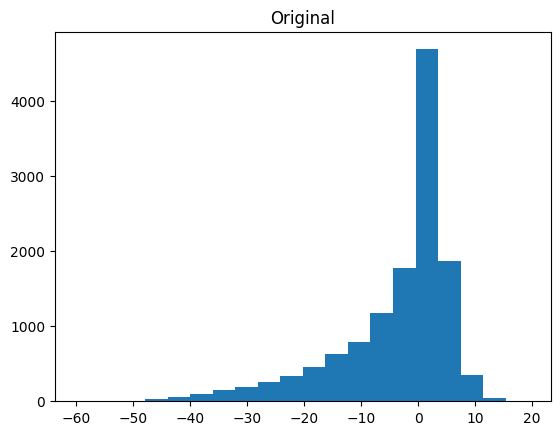

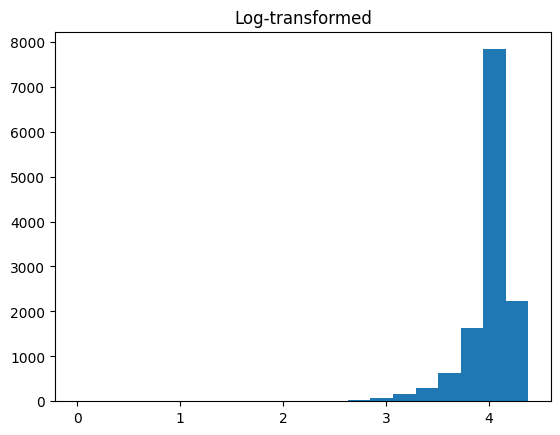


Log-transformation of the target is not applied



,SW_IN_POT,ppfd,ts_0.3_gfXG,timesince_harvest,ts_0.3_gfXG_roll3hmean,ts_0.3_gfXG_roll6hmean,ts_0.05_gfXG_lag3h_roll9hmean,ts_0.3_gfXG_lag9h_roll6hmean,ts_0.3_gfXG_lag9h_roll9hmean,id,NEE_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,
2023-11-22 11:15:00,508.623,100.485834,7.766860,36.0,7.835438,7.881068,4.413246,8.073868,8.105448,694,0.870527
2023-11-22 11:45:00,531.452,78.235791,7.739503,36.0,7.796506,7.868452,4.340476,8.069913,8.098096,695,0.844507
2023-11-22 12:15:00,539.106,82.407674,7.751822,37.0,7.760740,7.853238,4.315091,8.062211,8.085197,696,0.629330
2023-11-22 12:45:00,531.452,98.399892,7.714983,37.0,7.751738,7.833677,4.291413,8.054654,8.074308,697,0.602554
2023-11-22 13:15:00,508.623,117.173366,7.638218,37.0,7.729686,7.810645,4.266595,8.043696,8.061026,698,0.477717
...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,0.000,0.000000,17.300000,23.0,17.299259,17.243611,21.019567,16.969259,17.054537,27595,10.578562
2025-06-04 22:15:00,0.000,0.000000,17.300000,23.0,17.299907,17.260231,21.028580,16.955463,17.034259,27596,9.416519
2025-06-04 22:45:00,0.000,0.000000,17.269444,23.0,17.294907,17.268472,20.987808,16.946296,17.017191,27597,10.095010


In [8]:
min_value = data[TARGET].min()

def log_transform(x):
    return np.log1p(x - min_value) if min_value < 0 else np.log1p(x)

def inverse_log_transform(x):
    return np.expm1(x) + min_value if min_value < 0 else np.expm1(x)

# Show histogram of non-tranformed and transformed TARGET
plt.hist(data[TARGET], bins=20)
plt.title('Original')
plt.show()
plt.hist(log_transform(data[TARGET]), bins=20)
plt.title('Log-transformed')
plt.show()

if LOG_TRANSFORM:
    print('Log-tranformed')
    data[TARGET] = log_transform(data[TARGET])
    print(f'{TARGET} was log-transformed')
    # Show log-transformed timeseries
    data[TARGET].plot(x_compat=True, style='.', title='Log-transformed');
else:
    print('\nLog-transformation of the target is not applied\n')

data

# CROSS-VAL SPLITS


Using time-blocks (6 records on average) splits for cross-validation



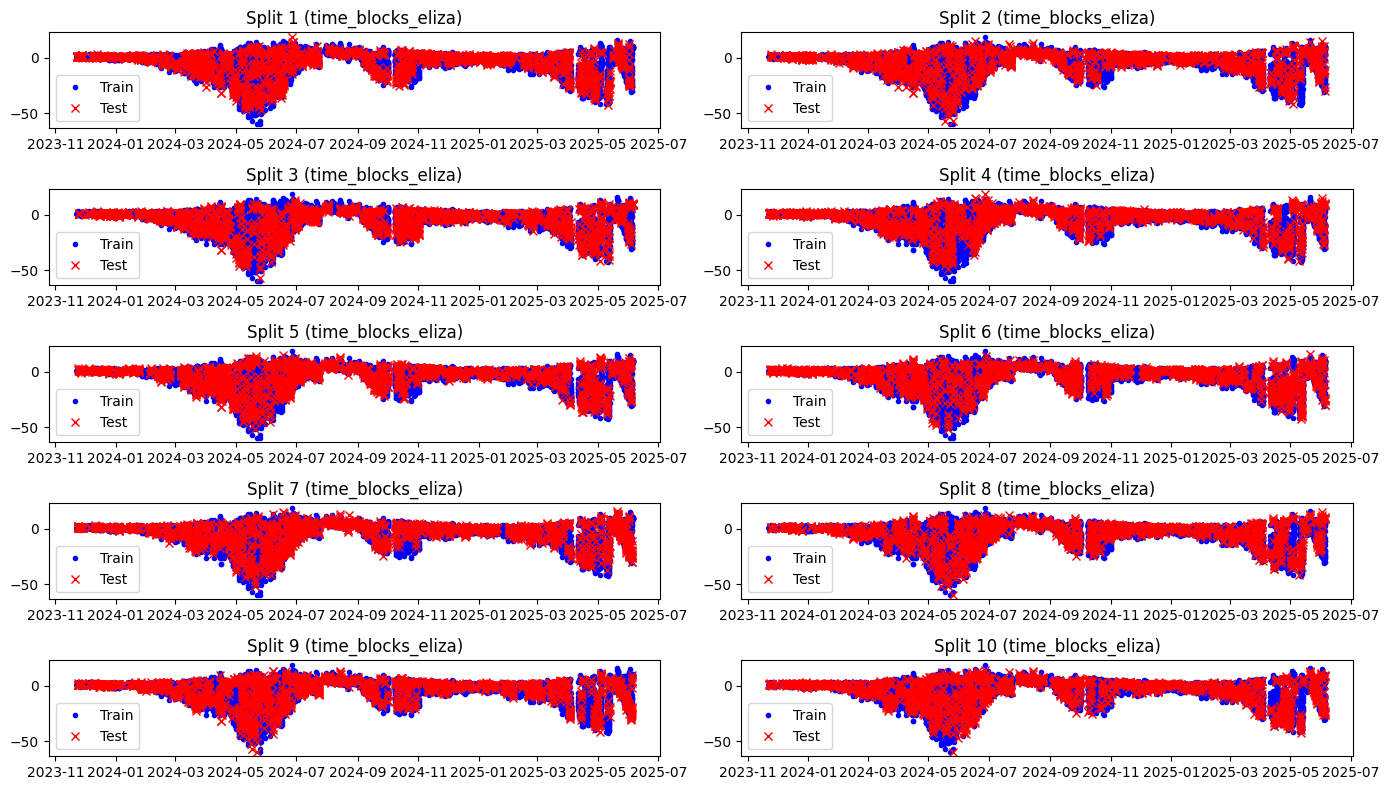

In [9]:
def create_splits(X, y, n_folds, test_size=0.2, random_state=42, n_bins=5):
    """Creates train-test splits using StratifiedShuffleSplit or StratifiedKFold with equal-width binning."""
    
    # Use pd.cut to create equal-width bins (avoids empty bins issue)
    y_binned = pd.cut(y, bins=n_bins, labels=False, include_lowest=True)

    # Select method for stratified splitting
    if CROSSVAL_SPLIT == "shuffle":
        splitter = StratifiedShuffleSplit(n_splits=n_folds, test_size=test_size, random_state=random_state)
        print('\nUsing stratified random splits for cross-validation\n')
    elif CROSSVAL_SPLIT == "kfold":
        splitter = StratifiedKFold(n_splits=n_folds, shuffle=False)
        print('\nUsing stratified kfold splits for cross-validation\n')

    # Generate train-test splits
    splits = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(X, y_binned)]

    return splits

if CROSSVAL_SPLIT == 'time_blocks_eliza':
    block_size = 6 
    print(f'\nUsing time-blocks ({block_size} records on average) splits for cross-validation\n')
    def create_splits(X, y, n_folds, split=0.2, mean_block=block_size, min_block=1, random_state=42): # you can set mean block to mean_nan_size
        """Generates multiple train-test index splits using block-based cross-validation by varying the random seed."""
        splits = []
        total_test = round(len(X) * split)
        n_blocks = round(total_test/mean_block)

        if mean_block < min_block:
            raise ValueError("Min block size is too large for the number of blocks.")

        for fold in range(n_folds):
            np.random.seed(random_state + fold)  # Change seed for each fold
            
            tt = np.zeros(len(X))  # Array to store train-test assignments

            # Generate random block sizes with normal variation
            blocks = np.array([max(min_block, mean_block + round(v)) 
                            for v in np.random.normal(0, mean_block / 10, n_blocks)])

            # Randomly shuffle the starting positions of test blocks
            available_positions = np.arange(len(X))  # Possible start positions
            np.random.shuffle(available_positions)   # Shuffle them

            # Assign blocks sequentially based on shuffled positions
            assigned = set()
            for b in blocks:
                if len(assigned) >= total_test:
                    break
                # Pick a random starting position
                istart = np.random.choice(available_positions)
                iend = min(istart + int(b), len(X))

                # Ensure blocks don't overlap significantly
                assigned.update(range(istart, iend))
                tt[istart:iend] = 1

            train_idx = np.where(tt == 0)[0]
            test_idx = np.where(tt == 1)[0]
            
            splits.append((train_idx, test_idx))

        return splits

X = data.drop(columns=TARGET)
y = data[TARGET]
# Create the splits using StratifiedShuffleSplit
cross_val_splits = create_splits(X, y, n_folds=N_FOLDS)


# --- PLOT TRAIN-TEST SPLITS ---
n_rows = math.ceil(N_FOLDS / 2)  # Ensure enough rows for all splits
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 8))
axes = axes.flatten()  # Flatten the axes array to make iteration easier

for i, (train_idx, test_idx) in enumerate(cross_val_splits):
    train_idx_mapped = X.iloc[train_idx].index
    test_idx_mapped = X.iloc[test_idx].index

    # Plot train and test points
    axes[i].plot(y.loc[train_idx_mapped].index, y.loc[train_idx_mapped], '.', label='Train', color="blue")
    axes[i].plot(y.loc[test_idx_mapped].index, y.loc[test_idx_mapped], 'x', label='Test', color="red")
    
    axes[i].set_title(f"Split {i + 1} ({CROSSVAL_SPLIT})")
    axes[i].legend()

# Hide unused subplots if n_folds is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# CROSS-VALIDATION

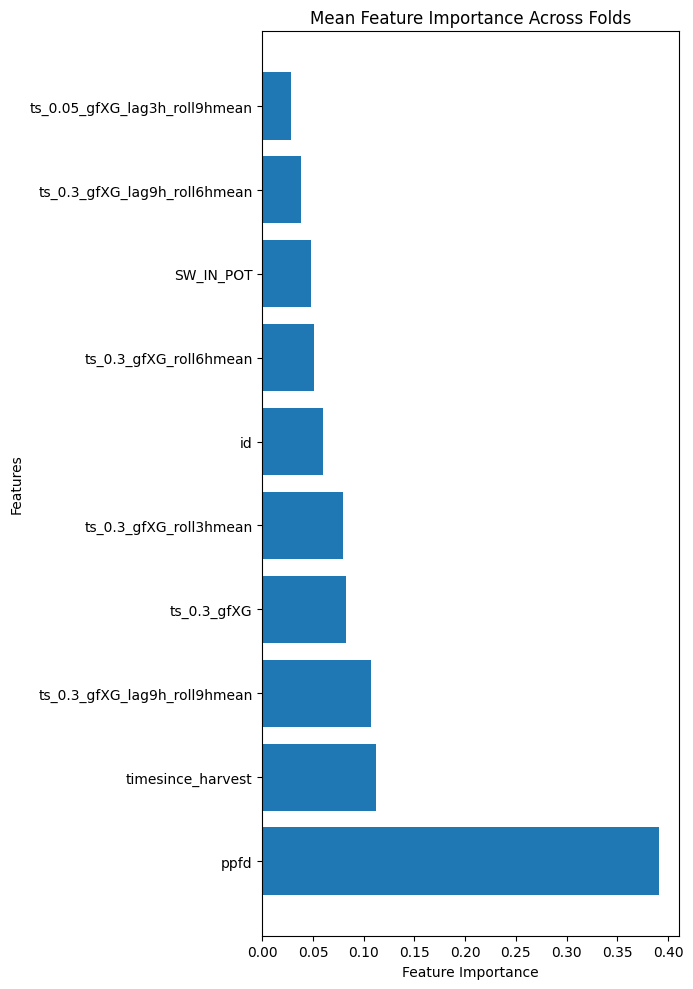

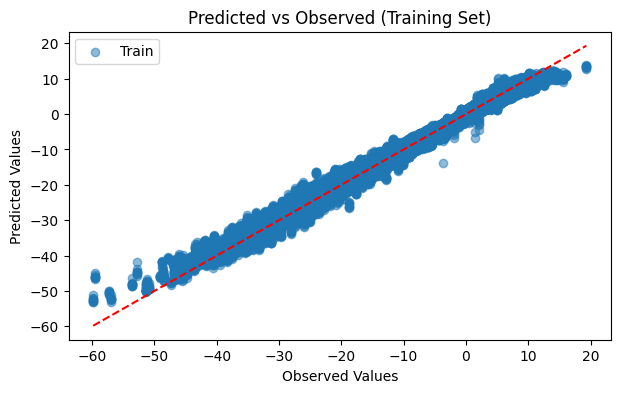

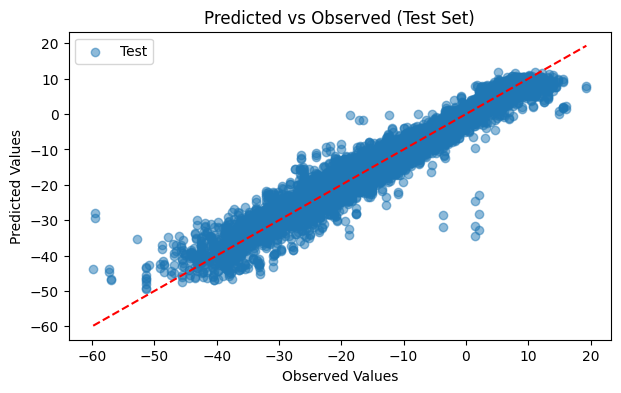

Train RMSE per fold: [0.9621 0.9574 0.9634 0.9588 0.9687 0.9693 0.9547 0.9499 0.956  0.9439]
Mean Train RMSE: 0.9584
Test RMSE per fold: [1.8832 1.9715 2.0032 2.0152 2.0397 1.9516 1.9724 2.2385 2.3777 2.0803]
Mean Test RMSE: 2.0533
Train R² per fold: [0.991  0.9916 0.9912 0.9914 0.991  0.9915 0.9914 0.9915 0.9913 0.9915]
Mean Train R²: 0.9913
Test R² per fold: [0.9706 0.958  0.9629 0.961  0.9637 0.9572 0.9635 0.9533 0.9494 0.9614]
Mean Test R²: 0.9601


In [10]:
X = data.drop(columns=TARGET)
y = data[TARGET]

# Store results
rmse_train_values, rmse_test_values = [], []
r2_train_values, r2_test_values = [], []
feature_importances_folds = []
y_train_all, y_train_pred_all = [], []
y_test_all, y_pred_test_all = [], []

# Perform cross-validation
for train_idx, test_idx in cross_val_splits:  
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    if LOG_TRANSFORM:
        y_train =  inverse_log_transform(y_train)
        y_test =  inverse_log_transform(y_test)
        y_train_pred =  inverse_log_transform(y_train_pred)
        y_test_pred =  inverse_log_transform(y_test_pred)

    # Store RMSE & R² for training and test sets
    rmse_train_values.append(root_mean_squared_error(y_train, y_train_pred))
    rmse_test_values.append(root_mean_squared_error(y_test, y_test_pred))
    r2_train_values.append(r2_score(y_train, y_train_pred))
    r2_test_values.append(r2_score(y_test, y_test_pred))

    # Store feature importances
    feature_importances_folds.append(model.feature_importances_)

    # Store predictions
    y_train_all.extend(y_train)
    y_train_pred_all.extend(y_train_pred)
    y_test_all.extend(y_test)
    y_pred_test_all.extend(y_test_pred)

# Compute mean feature importance across folds
feature_importances = np.nanmean(feature_importances_folds, axis=0)
# Sort feature importances
order = np.argsort(-feature_importances)  # Sort in descending order
feature_names = X_train.columns[order]  # Get feature names sorted by importance

# Plot sorted feature importances
fig, ax = plt.subplots(figsize=(7, 10))
ax.barh(feature_names, feature_importances[order])
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Features")
ax.set_title("Mean Feature Importance Across Folds")
fig.tight_layout()
plt.show()

# Plot Predicted vs Observed (Training Set)
plt.figure(figsize=(7, 4))
plt.scatter(y_train_all, y_train_pred_all, alpha=0.5, label="Train")
plt.plot([min(y_train_all), max(y_train_all)], [min(y_train_all), max(y_train_all)], color='red', linestyle='--')
plt.xlabel("Observed Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Observed (Training Set)")
plt.legend()
plt.show()

# Plot Predicted vs Observed (Test Set)
plt.figure(figsize=(7, 4))
plt.scatter(y_test_all, y_pred_test_all, alpha=0.5, label="Test")
plt.plot([min(y_test_all), max(y_test_all)], [min(y_test_all), max(y_test_all)], color='red', linestyle='--')
plt.xlabel("Observed Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Observed (Test Set)")
plt.legend()
plt.show()

# Print RMSE and R² for both Training and Test sets
print(f"Train RMSE per fold: {np.array(rmse_train_values).round(4)}")
print(f"Mean Train RMSE: {np.mean(rmse_train_values):.4f}")
print(f"Test RMSE per fold: {np.array(rmse_test_values).round(4)}")
print(f"Mean Test RMSE: {np.mean(rmse_test_values):.4f}")

print(f"Train R² per fold: {np.array(r2_train_values).round(4)}")
print(f"Mean Train R²: {np.mean(r2_train_values):.4f}")
print(f"Test R² per fold: {np.array(r2_test_values).round(4)}")
print(f"Mean Test R²: {np.mean(r2_test_values):.4f}")


# FINAL MODEL

## Split train-test

Block splitting with test blocks that can vary of size and we can define the minimum size

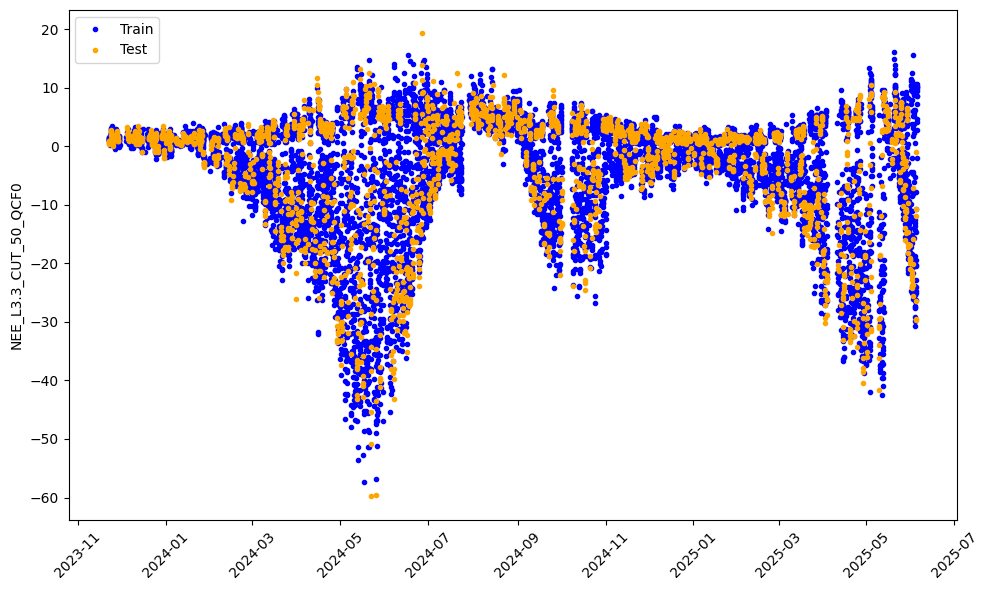

In [11]:
#mean_block = round(mean_nan_size)
mean_block = 6

def split_blocks(X, y, mean_block = mean_block, split=0.2, min_block=1):
       np.random.seed(42)  # Set seed for reproducibility
       tt = np.zeros(len(X)) # space for training/test assignments
       total_test = round(len(X)* split)
       n_blocks = round(total_test/mean_block)
       if mean_block<min_block:
              print("Error: Min block too long for this many blocks")
              return None
       # Vary the length of blocks around the mean (but not below the min)
       blocks = np.array([mean_block + round(v) for v in np.random.normal(0, mean_block/10, n_blocks)])
       blocks[blocks < min_block] = min_block
       # Assign the blocks
       for n, b in enumerate(blocks):
              istart = round(len(X)/(n_blocks))*(n-1)
              iend = istart+b
              tt[istart:iend] = 1
       X_train = X[tt==0]
       X_test = X[tt==1]
       y_train = y[tt==0]
       y_test = y[tt==1]
       # Return sorted data by index (timestamp)
       return X_train.sort_index(), X_test.sort_index(), y_train.sort_index(), y_test.sort_index(), tt

X = data.drop(columns=TARGET)
y = data[TARGET]
X_train, X_test, y_train, y_test, tt = split_blocks(X, y, mean_block=mean_block) # set number of blocks
              
# Check the split
fig, ax = plt.subplots(figsize=(10, 6))  # Adjusted size for better readability
ax.plot(y_train.index, y_train, ".", label="Train", color='blue')
ax.plot(y_test.index, y_test, ".", label="Test", color='orange')
ax.set_ylabel(TARGET)
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()

# Show the plot
plt.show()

## Model training and testing

[0]	validation_0-rmse:10.27180
[1]	validation_0-rmse:10.17962
[2]	validation_0-rmse:10.08875
[3]	validation_0-rmse:9.99779
[4]	validation_0-rmse:9.90845
[5]	validation_0-rmse:9.82032
[6]	validation_0-rmse:9.73179
[7]	validation_0-rmse:9.64366
[8]	validation_0-rmse:9.55730
[9]	validation_0-rmse:9.47181
[10]	validation_0-rmse:9.38660
[11]	validation_0-rmse:9.30241
[12]	validation_0-rmse:9.22011
[13]	validation_0-rmse:9.13813
[14]	validation_0-rmse:9.05711
[15]	validation_0-rmse:8.97789
[16]	validation_0-rmse:8.89684
[17]	validation_0-rmse:8.81806
[18]	validation_0-rmse:8.74195
[19]	validation_0-rmse:8.66449
[20]	validation_0-rmse:8.58799
[21]	validation_0-rmse:8.51264
[22]	validation_0-rmse:8.43720
[23]	validation_0-rmse:8.36244
[24]	validation_0-rmse:8.28816
[25]	validation_0-rmse:8.21525
[26]	validation_0-rmse:8.14453
[27]	validation_0-rmse:8.07303
[28]	validation_0-rmse:8.00303
[29]	validation_0-rmse:7.93345
[30]	validation_0-rmse:7.86403
[31]	validation_0-rmse:7.79609
[32]	validation

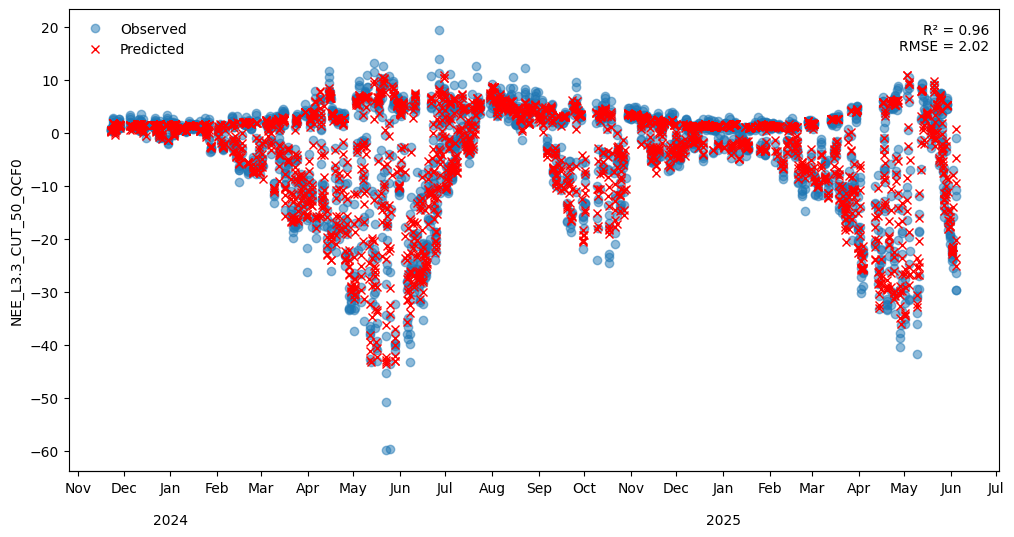

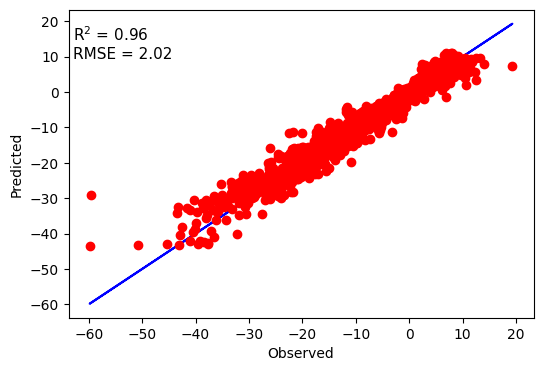

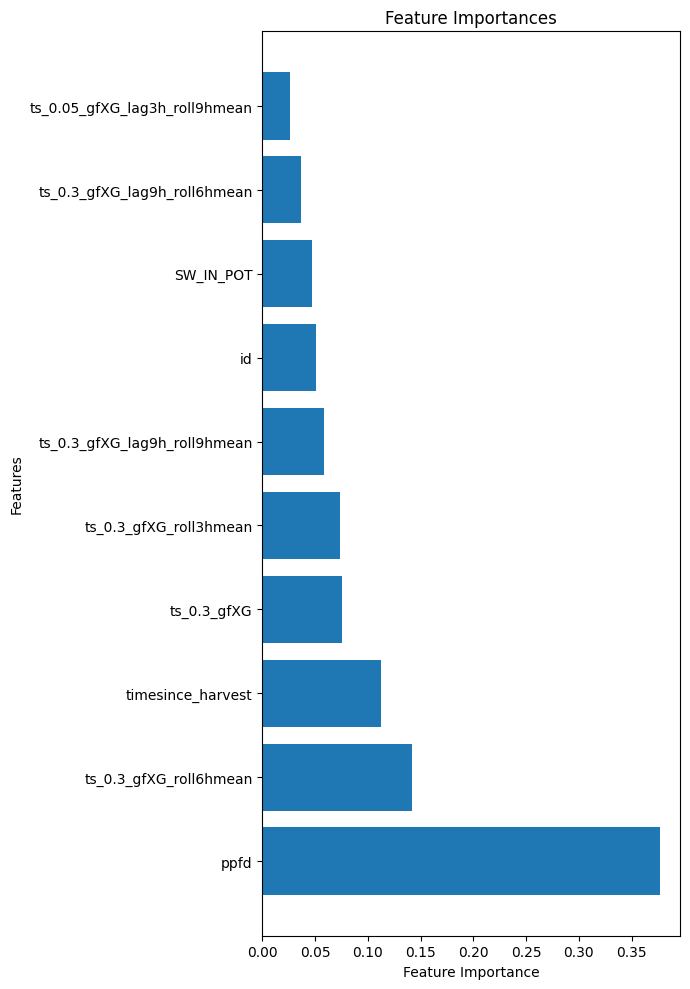

In [12]:
# Use early stopping if using XGBoost
model = RandomForestRegressor(**hyperparams, random_state=42, n_jobs=-1, early_stopping_rounds=10, eval_metric="rmse") if MODEL_TYPE == 'RandomForest' else XGBRegressor(**hyperparams, random_state=42, n_jobs=-1, early_stopping_rounds=10, eval_metric="rmse")

# Predict test set
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=True)
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

# Reverse the log transformation on the predictions and the original transformed data when the transformation was used
if LOG_TRANSFORM:
    pred_train = inverse_log_transform(pred_train) 
    pred_test = inverse_log_transform(pred_test)
    y_train = inverse_log_transform(y_train)
    y_test = inverse_log_transform(y_test)

# Calculate R-squared and Mean Squared Error (MSE) for the training set
r2_train = r2_score(y_train, pred_train)
print(f"R-squared (Training set): {r2_train:.4f}")
rmse_train = root_mean_squared_error(y_train, pred_train)
print(f"Root Mean Squared Error (Training set): {rmse_train:.4f}")
# Calculate R-squared and Mean Squared Error (MSE) for the test set
r2_test = r2_score(y_test, pred_test)
print(f"R-squared (Test set): {r2_test:.4f}")
rmse_test = root_mean_squared_error(y_test, pred_test)
print(f"Root Mean Squared Error (Test set): {rmse_test:.4f}")

# Time series plot
fig, ax = plt.subplots(1,figsize=(12, 6))
ax.plot(y_test.index, y_test,"o",label=("Observed"), alpha=0.5)
ax.plot(y_test.index, pred_test,"rx",label=("Predicted"))
# Format x-axis for months
ax.xaxis.set_major_locator(mdates.MonthLocator())  # Major ticks for months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as month abbreviation
# Add secondary x-axis for years
secax = ax.secondary_xaxis('bottom')
secax.xaxis.set_major_locator(mdates.YearLocator())  # Year ticks
secax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format as year
secax.tick_params(axis='x', length=0, pad=30)  # Add padding for better readability
# Add R2 and RMSE text
ax.text(0.99, 0.97, f'R² = {r2_test:.2f}\nRMSE = {rmse_test:.2f}',
        transform=ax.transAxes, va='top', ha='right')
ax.set_ylabel(TARGET)
ax.legend(frameon=False, loc="upper left")
# save fig
plt.savefig(f'plots/{TARGET}_NightTime_gapfilling_testset_performance.png', dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Obs Vs predicted
fig, ax = plt.subplots(1,figsize=(6,4))
ax.plot(y_test,y_test,"b-")
ax.plot(y_test,pred_test,"ro")
# Add R2 and RMSE text
ax.text(0.01, 0.95, f'R$^{2}$ = {r2_test:.2f}\nRMSE = {rmse_test:.2f}',
        transform=ax.transAxes, va='top', fontsize=11)
ax.set_xlabel("Observed")
ax.set_ylabel("Predicted")
plt.show()

# Plot feature importances
importances = model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]  # Sort descending
feature_names_sorted = X_train.columns[sorted_idx]

fig, ax = plt.subplots(figsize=(7, 10))
ax.barh(feature_names_sorted, importances[sorted_idx])
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Features")
ax.set_title("Feature Importances")
plt.tight_layout()
plt.show()

# SHAP ANALYSIS

## RUN SHAP

In [13]:
# define background dataset
background_dataset = data_main[selected_features]

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(model, data=background_dataset)

# Calculate SHAP values for the entire dataset
X = data_main[selected_features]
shap_values = explainer(X, check_additivity=True)

# Print the expected value
print("Baseline (expected value):", explainer.expected_value)
if LOG_TRANSFORM:
    print("Baseline without transformation (expected value):", inverse_log_transform(explainer.expected_value))

100%|===================| 27642/27648 [48:02<00:00]        

Baseline (expected value): -0.31474925747328064


## SUMMARY PLOT

C:\Users\turcof\AppData\Local\Temp\ipykernel_3916\1357068598.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, show=False)


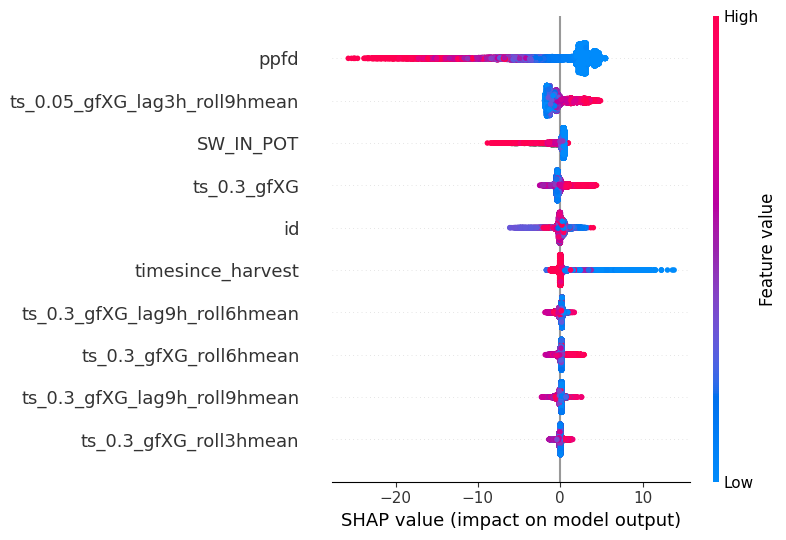

In [14]:
# SHAP summary plot
fig = plt.figure()
shap.summary_plot(shap_values, X, show=False)
# Save the figure
fig.savefig(f'plots/{TARGET}_NightTime_shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## SHAP SCATTERPLOTS

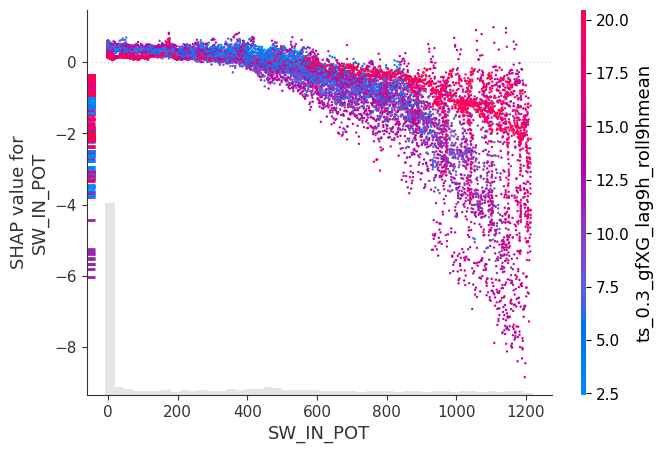

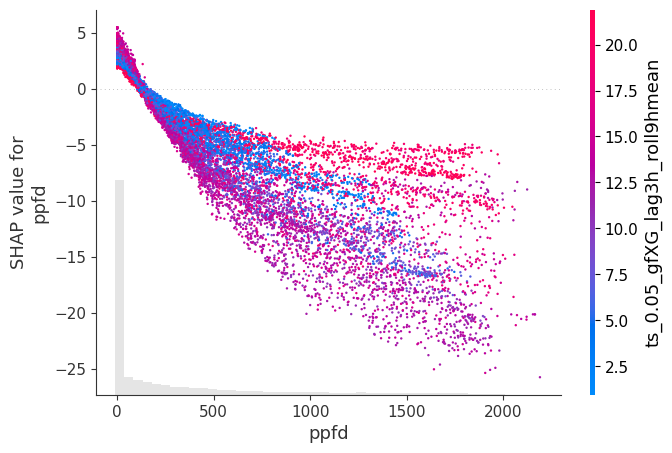

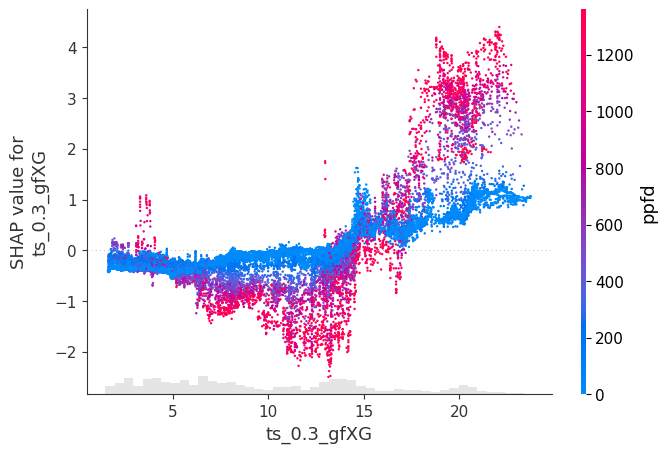

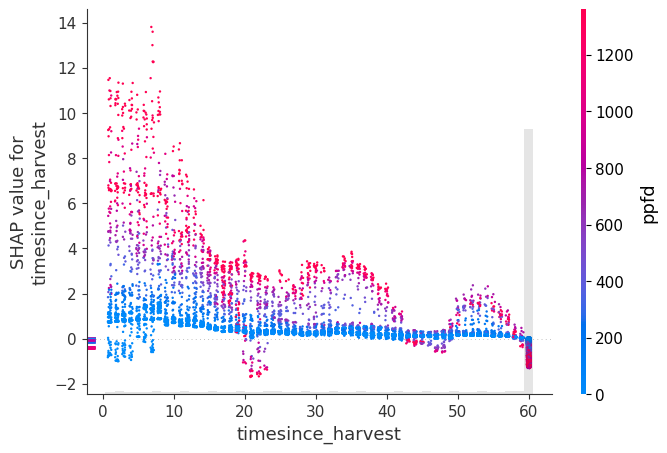

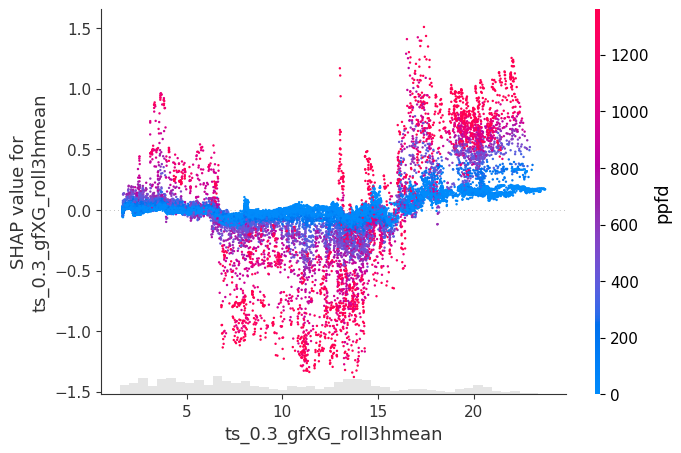

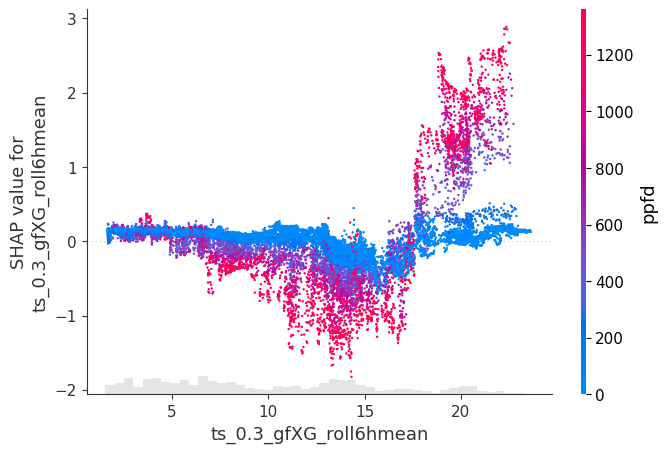

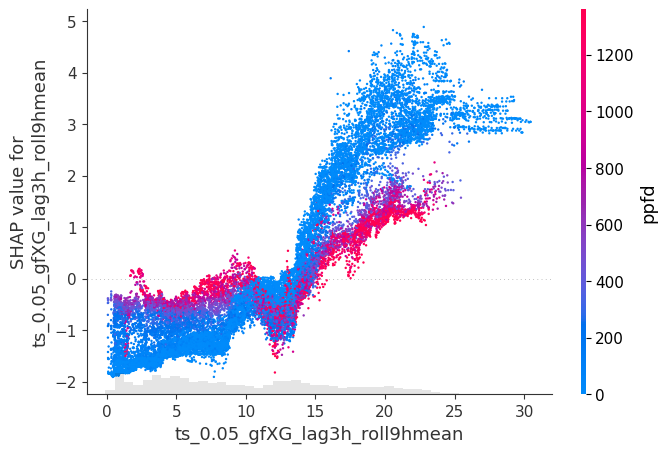

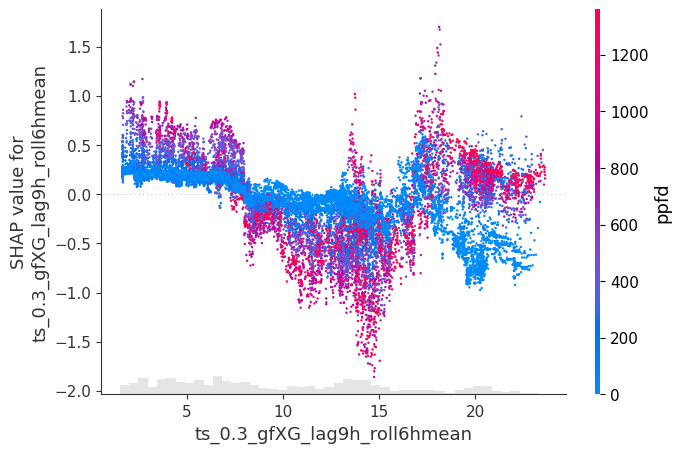

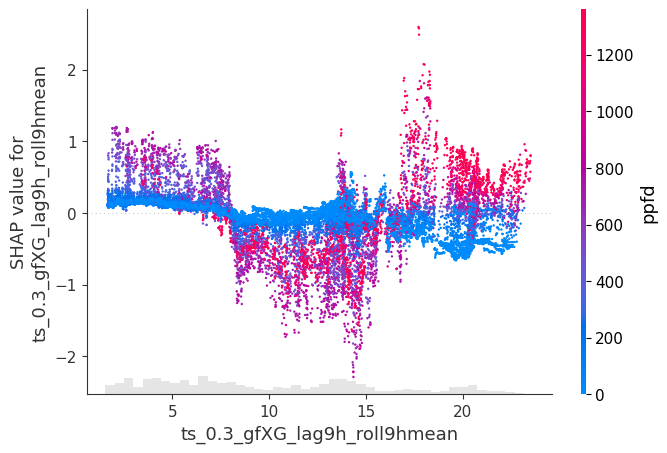

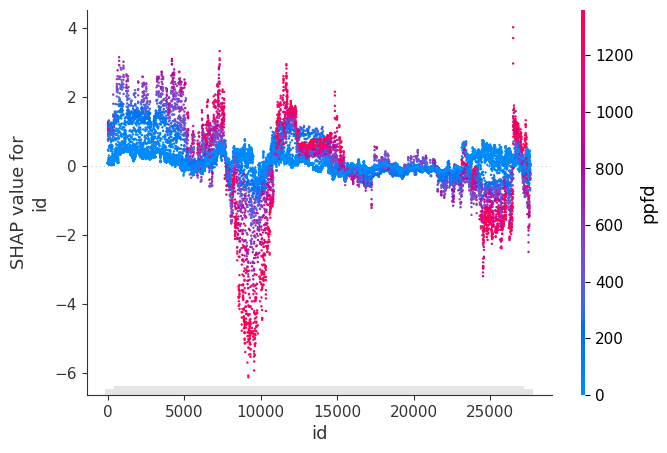

In [15]:
# Dependence plots

for var in X.columns:
    shap.plots.scatter(shap_values[:, var], dot_size=3, x_jitter=0.5, color=shap_values)
#    shap.dependence_plot(var, shap_values.values, X)
    plt.show()

# GAP-FILLING

In [13]:
QCFLAGS = ['QCF', 'QCF0']

for _qc in QCFLAGS:
    GAPFILLING_TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_{_qc}'

    # POOLED NIGHT GAPFILL (no parcel-specific features)
    # Predict everywhere with your pooled night model
    X = data_main[selected_features].copy()
    yhat = model.predict(X).astype(np.float64)
    if LOG_TRANSFORM:
        yhat = inverse_log_transform(yhat)
    # Write outputs (start from predictions, then overwrite with observations)
    col_pred = f"{TARGET_FLUX}_{MODEL_TYPE}_predictions"
    col_gf  = f"{GAPFILLING_TARGET}_gf{MODEL_TYPE}"
    # Start with pooled predictions
    data_main[col_pred] = yhat
    data_main[col_gf]  = yhat
    # We assume there was no difference at night between parcels --> result will be the same
    m_all     = data_main[GAPFILLING_TARGET].notna()
    # overwrite with observed target
    data_main.loc[m_all, col_gf]  = data_main.loc[m_all, GAPFILLING_TARGET].astype(np.float64)
    # Add FLAG (1 = filled, 0 = observed, <NA> = no value)
    flag_col = f'FLAG_{GAPFILLING_TARGET}_gf{MODEL_TYPE}_ISFILLED'
    flag = pd.Series(1, index=data_main.index, dtype='Int8')
    flag.loc[m_all] = 0                            
    flag.loc[data_main[col_gf].isna()] = pd.NA        
    data_main[flag_col] = flag

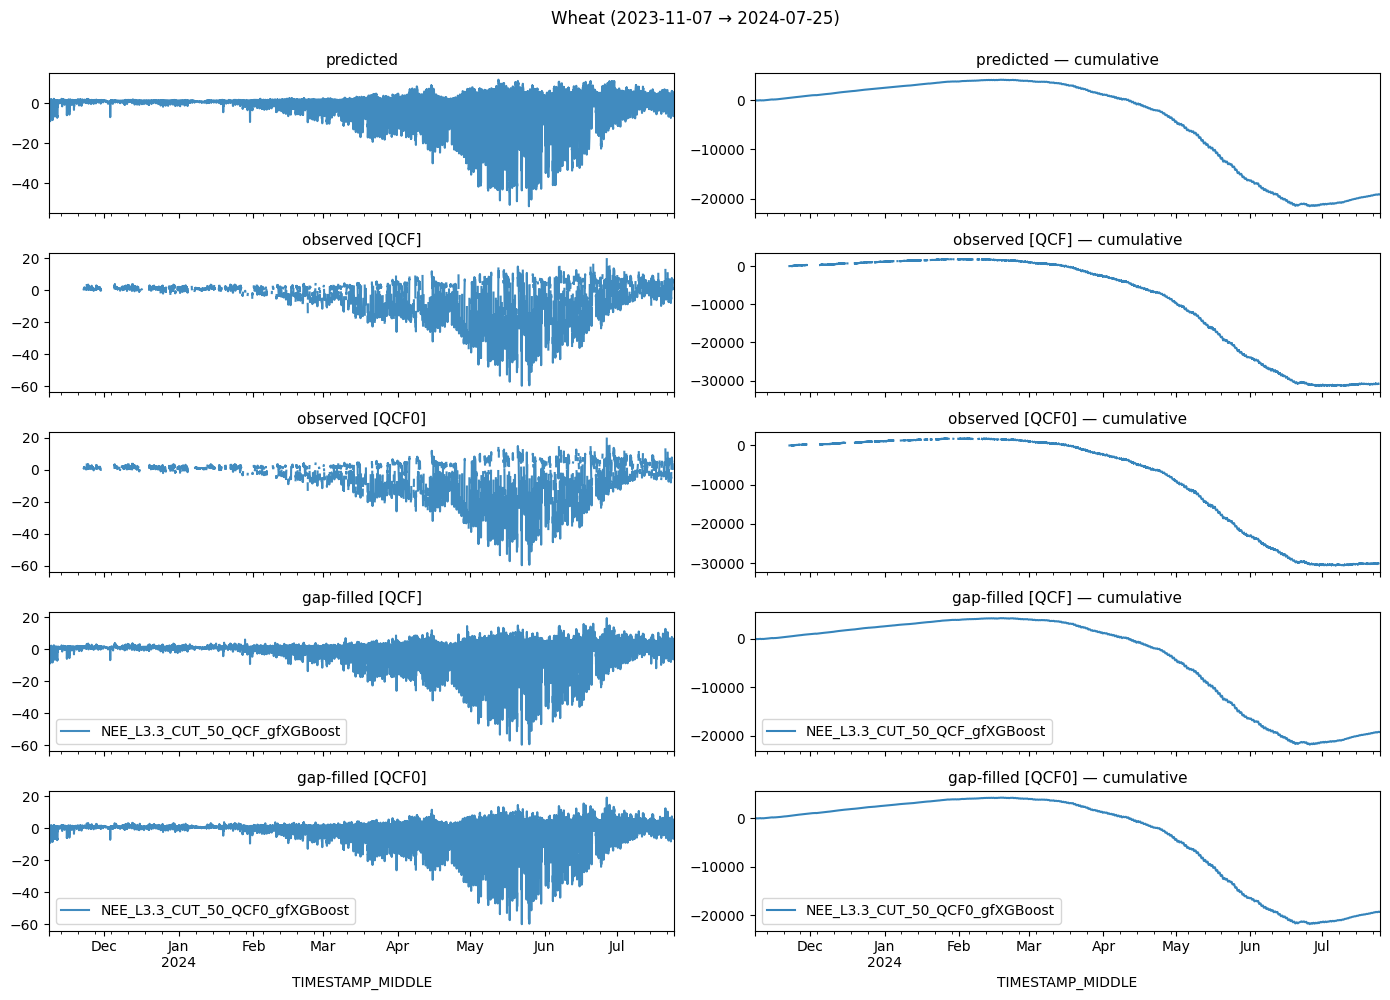

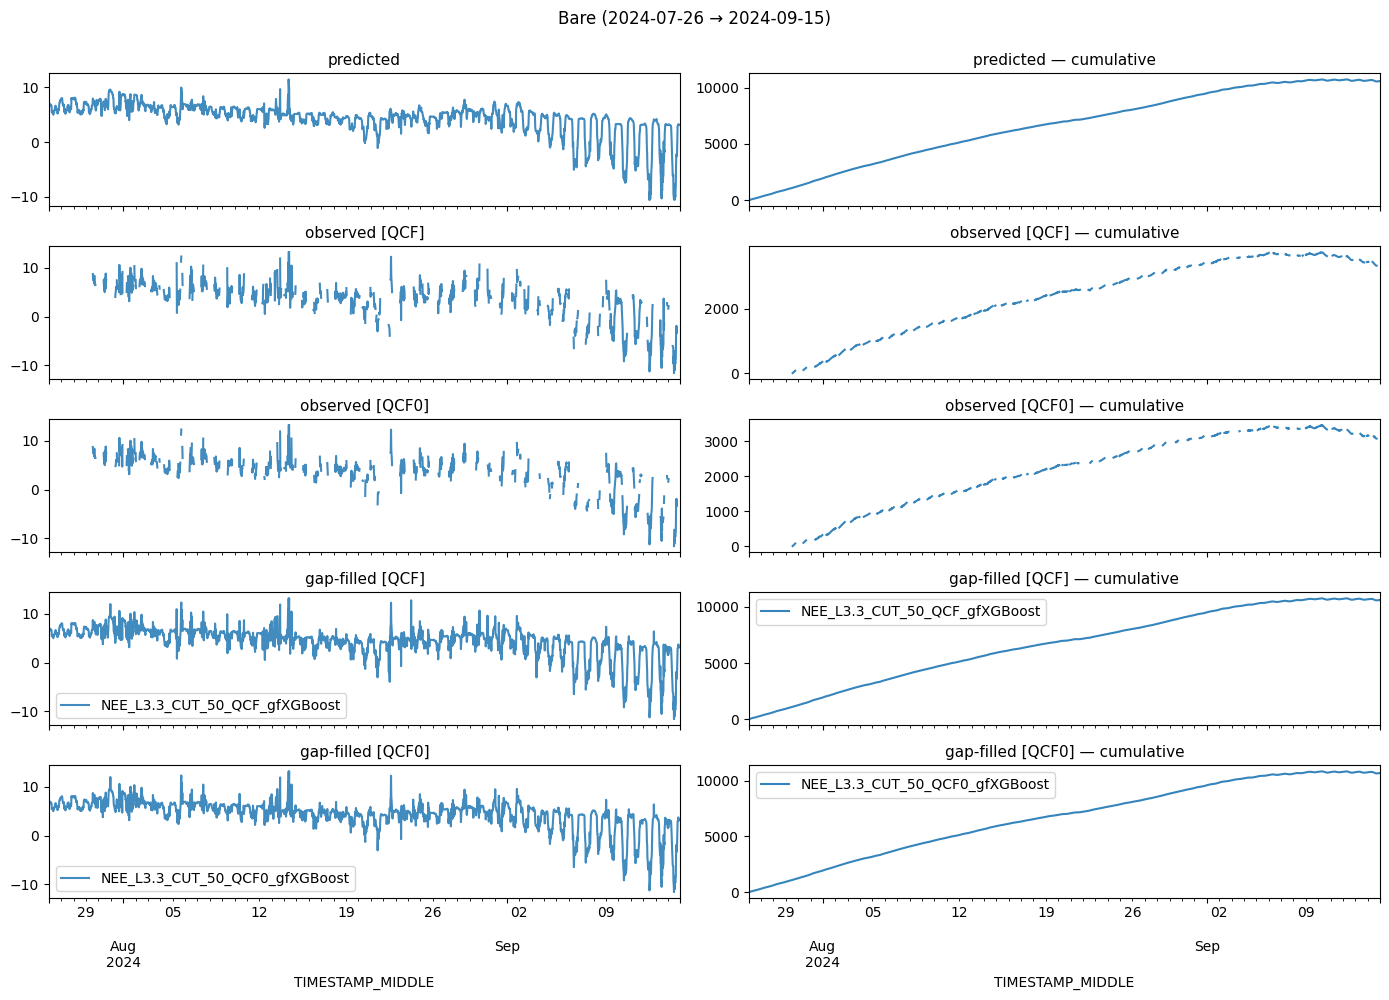

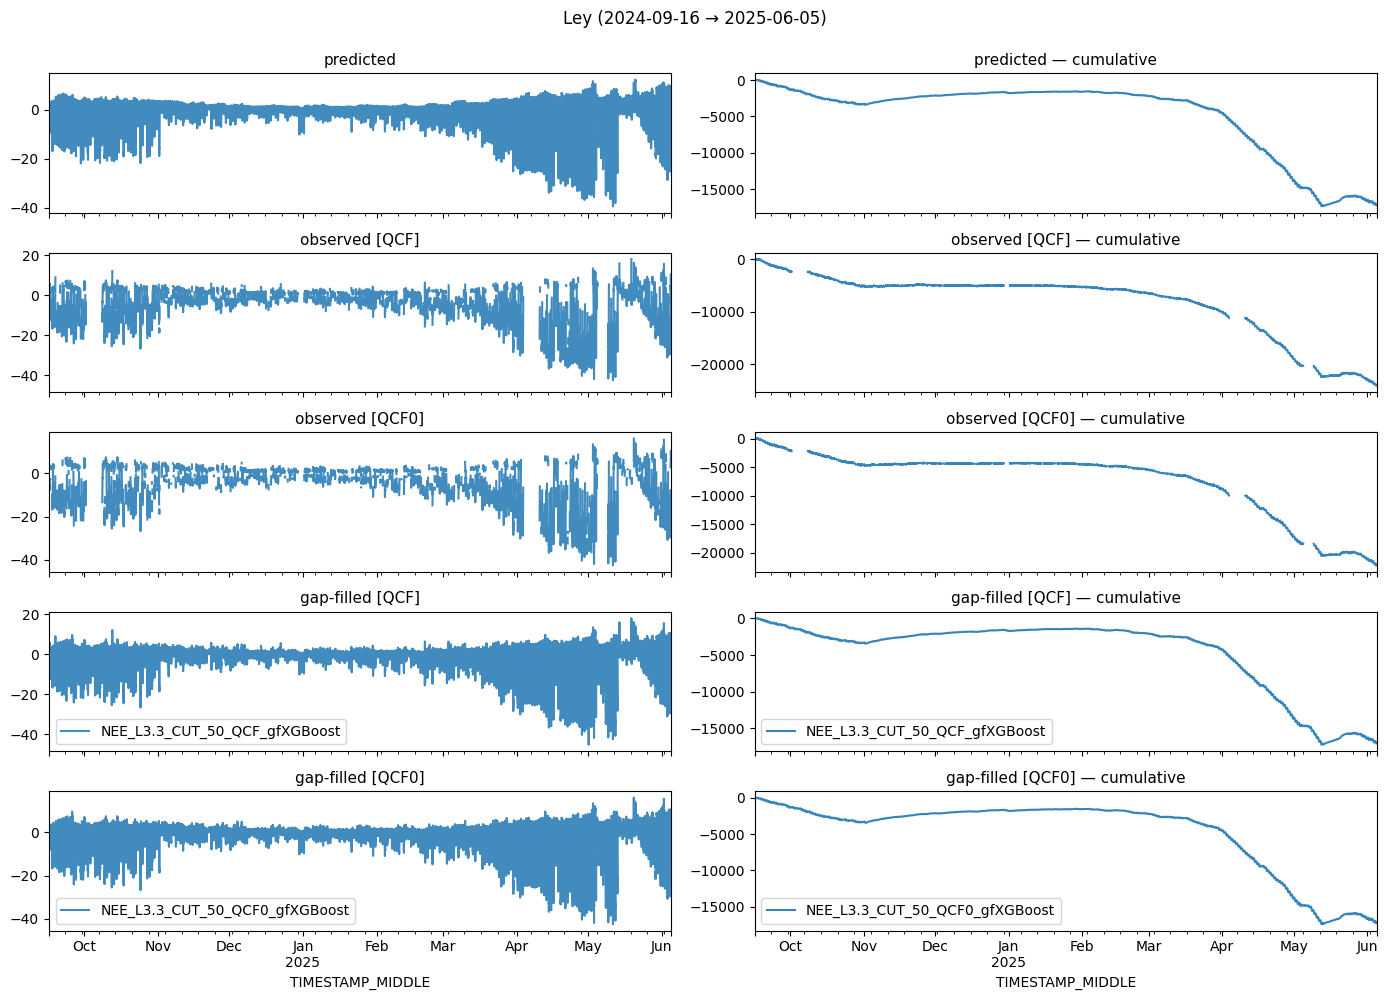

In [14]:
# Plots

# Define periods
periods = [
    ("2023-11-07", "2024-07-25", "Wheat"),
    ("2024-07-26", "2024-09-15", "Bare"),
    ("2024-09-16", "2025-06-05", "Ley"),
]

# periods = [
#     ("2024-02-07", "2024-02-10", "Wheat"),
#     ("2024-08-01", "2024-08-04", "Bare"),
#     ("2025-03-16", "2025-03-29", "Ley"),
# ]

QCFLAGS = ['QCF', 'QCF0']     # order: show QCF first, then QCF0

def tgt(qc): 
    return f'{TARGET_FLUX}_L3.3_CUT_50_{qc}'

for start, end, label in periods:
    period_df = data_main.loc[pd.to_datetime(start):pd.to_datetime(end)]
    rows = []   # list of (cols, title)

    # PREDICTED
    rows.append((col_pred, "predicted"))
    # OBSERVED — QCF then QCF0
    for qc in QCFLAGS:
        col = tgt(qc)
        rows.append((col, f"observed [{qc}]"))
    # GAP-FILLED  — QCF then QCF0
    for qc in QCFLAGS:
        _t = tgt(qc)
        col = [f"{_t}_gf{MODEL_TYPE}"]
        rows.append((col, f"gap-filled [{qc}]"))

    nrows, ncols = len(rows), 2  # raw & cumulative
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 2*nrows), sharex='col')

    for r, (cols, title) in enumerate(rows):
        # RAW
        period_df[cols].plot(ax=axes[r, 0], alpha=0.85)
        axes[r, 0].set_title(title, fontsize=11)
        # CUMULATIVE
        cumulative = period_df[cols].cumsum()
        cumulative.plot(ax=axes[r, 1], alpha=0.9)
        axes[r, 1].set_title(f"{title} — cumulative", fontsize=11)

    fig.suptitle(f"{label} ({start} → {end})", y=0.995, fontsize=12)
    plt.tight_layout()
    plt.show()


# EXPORT

In [15]:
newcols = [c for c in data_main.columns if c not in maindf if f'gf{MODEL_TYPE}' in c]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET_FLUX}:")
for c in newcols:
    print(f"+ {c}")

NEW VARIABLES FROM GAP-FILLING NEE:
+ NEE_L3.3_CUT_50_QCF_gfXGBoost
+ FLAG_NEE_L3.3_CUT_50_QCF_gfXGBoost_ISFILLED
+ NEE_L3.3_CUT_50_QCF0_gfXGBoost
+ FLAG_NEE_L3.3_CUT_50_QCF0_gfXGBoost_ISFILLED


In [17]:
filename = f"81.4.1_{TARGET_FLUX}_GF-{MODEL_TYPE}"
df_export = data_main[newcols]
save_parquet(filename=filename, data=df_export)

Saved file 81.4.1_NEE_GF-XGBoost.parquet (0.164 seconds).


'81.4.1_NEE_GF-XGBoost.parquet'

Partitioning subset for ReddyProc

In [18]:
from diive.core.times.times import insert_timestamp
meteo = load_parquet(filepath=r"../../10_METEO/13.1_CH-TAN_meteo_gapfilled.parquet")
fluxes = load_parquet(filepath=r"../../70_SPLIT_TREATMENTS/71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS.parquet")
fluxes = fluxes['USTAR']
meteo = meteo[['ta', 'sw_in', 'vpd', 'ppfd', 'rh']]
export_REddyProc = pd.concat([df_export, meteo, fluxes], axis=1)
export_REddyProc = insert_timestamp(data=export_REddyProc, convention="end", set_as_index=True)
filename = "81.4.2_PartitioningSubsetForREddyProc"
export_REddyProc.to_csv(f"{filename}.csv", index=True)
print(f"Exported {filename} for partitioning of the XGBoost-gapfilled NEE")
export_REddyProc

Loaded .parquet file ../../10_METEO/13.1_CH-TAN_meteo_gapfilled.parquet (0.221 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
Loaded .parquet file ../../70_SPLIT_TREATMENTS/71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS.parquet (0.592 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
Exported 81.4.2_PartitioningSubsetForREddyProc for partitioning of the XGBoost-gapfilled NEE


,NEE_L3.3_CUT_50_QCF_gfXGBoost,FLAG_NEE_L3.3_CUT_50_QCF_gfXGBoost_ISFILLED,NEE_L3.3_CUT_50_QCF0_gfXGBoost,FLAG_NEE_L3.3_CUT_50_QCF0_gfXGBoost_ISFILLED,ta,sw_in,vpd,ppfd,rh,USTAR
TIMESTAMP_END,,,,,,,,,,
2023-11-01 00:00:00,NaN,<NA>,NaN,<NA>,8.000000,0.0,0.216913,0.0,79.800000,NaN
2023-11-01 00:30:00,NaN,<NA>,NaN,<NA>,8.633333,0.0,0.272054,0.0,75.733333,NaN
2023-11-01 01:00:00,NaN,<NA>,NaN,<NA>,8.266667,0.0,0.257705,0.0,76.433333,NaN
2023-11-01 01:30:00,NaN,<NA>,NaN,<NA>,6.966667,0.0,0.171078,0.0,82.900000,NaN
2023-11-01 02:00:00,NaN,<NA>,NaN,<NA>,5.666667,0.0,0.104550,0.0,88.566667,NaN
...,...,...,...,...,...,...,...,...,...,...
2025-06-05 22:00:00,7.543205,1,7.543205,1,15.833333,0.0,0.285270,0.0,84.166667,NaN
2025-06-05 22:30:00,7.461149,1,7.461149,1,15.733333,0.0,0.289417,0.0,83.833333,NaN
2025-06-05 23:00:00,7.744204,1,7.744204,1,16.200000,0.0,0.404542,0.0,78.066667,NaN


# End of notebook

In [19]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-12-11 11:43:31
